# DengAI · 4. Validation design and model selection

1. A cross-validation procedure that imitates the real forecasting task
2. The quality measure
3. Baselines
4. City-specific tree ensembles + grid search
5. MLP: comparing the three climate representations
6. MLP: hyper-parameter search, judged against seed noise
7. Ablation: forecast lead time
8. Overall comparison and a tree + MLP blend
9. A test-like multi-year holdout
10. Local validation vs the hidden leaderboard: which model to submit

Runtime: about 6–8 minutes on a laptop CPU (the MLP is pure NumPy).

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "dengai").is_dir())
sys.path.insert(0, str(ROOT))
OUTPUT_DIR = ROOT / "notebooks" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

import json
import time
from dataclasses import replace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from sklearn.model_selection import KFold

from dengai import features as F
from dengai.config import (CITIES, CITY_NAMES, DATE_COLUMN, FINAL_MLP_CONFIGS, TARGET_COLUMN, TEST_WEEKS,
                           MLPConfig)
from dengai.data import city_frame, find_data_dir, load_data
from dengai.models import seasonal_baseline, median_baseline, to_cases, tree_model
from dengai.plotting import CITY_COLORS, MUTED, SERIES, set_style
from dengai.validation import (cross_validate, fold_scores, interpolated_cities, predict_mlp, predict_tree,
                               summarize, temporal_folds)

set_style()
train, test, template = load_data(find_data_dir(ROOT))
cities = interpolated_cities(train)
SEEDS = (17, 42, 73)

## 1. Cross-validation procedure

Notebook 02 showed that weekly cases are strongly autocorrelated and that
the test set is a **multi-year block after** the training data. The
validation therefore has to:

* **train only on the past.** Each fold trains on every week before a
  validation year (an *expanding window*) and never shuffles rows;
* **forecast a whole year.** That covers a full seasonal cycle and forces
  predictions far from the last training label, as in the test;
* **cover several years.** Outbreak and quiet years differ a lot, so we
  average over the **last 3 years** of each city.

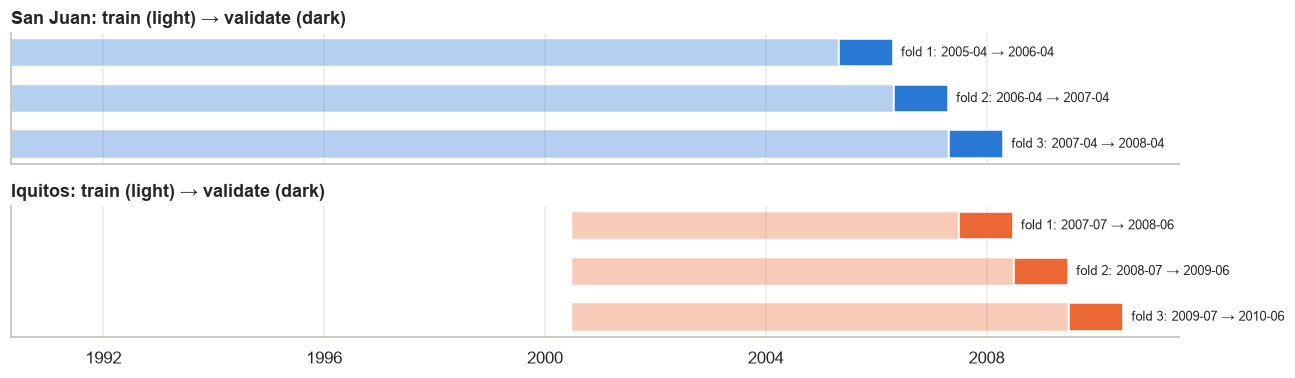

In [2]:
folds = {city: temporal_folds(cities, city, n_folds=3, fold_weeks=52) for city in CITIES}

fig, axes = plt.subplots(2, 1, figsize=(12, 3.6), sharex=True)
for ax, city in zip(axes, CITIES):
    for k, fold in enumerate(folds[city]):
        t0, t1 = fold.train[DATE_COLUMN].iloc[[0, -1]]
        v0, v1 = fold.valid[DATE_COLUMN].iloc[[0, -1]]
        ax.barh(k, t1 - t0, left=t0, color=CITY_COLORS[city], alpha=0.35, height=0.6)
        ax.barh(k, v1 - v0, left=v0, color=CITY_COLORS[city], height=0.6)
        ax.text(v1, k, f"  fold {fold.number}: {fold.label}", va="center", fontsize=8.5)
    ax.set(yticks=[], title=f"{CITY_NAMES[city]}: train (light) → validate (dark)")
    ax.invert_yaxis()
plt.tight_layout()

**Why not ordinary shuffled K-fold?** A shuffled split puts the
neighbours of every validation week into the training set. Because
adjacent weeks are almost identical, the model only has to interpolate,
which gives an over-optimistic score. With the same tree model:

In [3]:
rows = []
for city in CITIES:
    frame = city_frame(train, city)
    x, y = F.tree_features(frame), frame[TARGET_COLUMN].to_numpy()
    for k, (tr, va) in enumerate(KFold(5, shuffle=True, random_state=0).split(x)):
        model = tree_model(city, n_estimators=200).fit(x.iloc[tr], y[tr])
        rows.append({"City": CITY_NAMES[city], "scheme": "shuffled 5-fold",
                     "MAE": np.abs(to_cases(model.predict(x.iloc[va]), "round") - y[va]).mean()})
    for fold in folds[city]:
        prediction = predict_tree(fold, train, n_estimators=200)
        rows.append({"City": CITY_NAMES[city], "scheme": "expanding window (ours)",
                     "MAE": np.abs(prediction - fold.valid[TARGET_COLUMN].to_numpy()).mean()})
leak = pd.DataFrame(rows)
leak.groupby(["City", "scheme"])["MAE"].mean().unstack().round(2)

scheme,expanding window (ours),shuffled 5-fold
City,,
Iquitos,7.27,4.37
San Juan,12.87,12.60


For Iquitos, shuffled CV reports an error about 40% smaller than an
honest forecast of the next year. For San Juan the gap is small for this
model, but shuffled folds still mix years and would not reveal how a
model behaves on an unseen season. Selecting models with shuffled CV
would favour models that memorise neighbouring weeks. **All comparisons below use the expanding-window
folds.**

## 2. Quality measure

* **MAE** (mean absolute error, cases per week) is the primary measure.
  It is the competition metric, easy to interpret, and less dominated
  by a single extreme outbreak week than RMSE (EDA §2).
* **Outbreak MAE**: MAE on weeks at or above the 90th percentile of the
  cases seen in training. It shows whether a model only gets quiet weeks
  right.
* **Weighted MAE**: the two cities' MAEs weighted by their test sizes
  (260 / 416 for San Juan, 156 / 416 for Iquitos). This mirrors the pooled
  leaderboard score.

Each model is scored on 3 folds; the neural network also on 3 random
seeds, so its scores average 9 runs.

## 3. Baselines

In [4]:
def baseline_predictions():
    frames = []
    for city in CITIES:
        frames.append(cross_validate(
            folds[city], lambda f: np.rint(median_baseline(f.train[TARGET_COLUMN], len(f.valid))).astype(int),
            model="Median baseline", seed=0))
        frames.append(cross_validate(
            folds[city], lambda f: np.rint(seasonal_baseline(
                f.train["weekofyear"], f.train[TARGET_COLUMN], f.valid["weekofyear"])).astype(int),
            model="Seasonal median", seed=0))
    return pd.concat(frames, ignore_index=True)

baselines = baseline_predictions()
summarize(baselines, ["model"])[1].round(2)

,model,iq,sj,weighted
0,Median baseline,7.69,21.22,16.15
1,Seasonal median,7.39,19.21,14.78


Any useful model must beat the **seasonal median** (the typical number of
cases for this week of the year).

## 4. Tree ensembles with a grid search

Model choice (motivated by notebook 02):

* **San Juan: Extra Trees with a Poisson split criterion** on the tabular
  features. Averaging randomised trees handles correlated inputs and
  nonlinear thresholds. The Poisson criterion suits overdispersed counts.
* **Iquitos: Random Forest on `log1p(cases)`.** The log compresses the
  rare spikes of a small, zero-heavy series.

Grid: `max_features` (the share of features tried at each split; lower means
more decorrelated trees) × `min_samples_leaf` (larger means smoother
predictions), 300 trees each.

18 configurations × 3 folds in 20s


{'sj': {'max_features': 1.0, 'min_samples_leaf': 5, 'mae': np.float64(12.99)},
 'iq': {'max_features': 0.7, 'min_samples_leaf': 5, 'mae': np.float64(7.2)}}

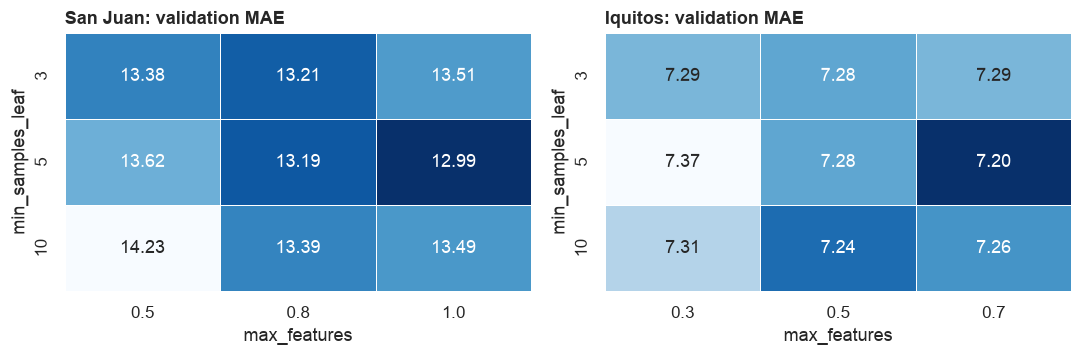

In [5]:
TREE_GRID = {
    "sj": {"max_features": [0.5, 0.8, 1.0], "min_samples_leaf": [3, 5, 10]},
    "iq": {"max_features": [0.3, 0.5, 0.7], "min_samples_leaf": [3, 5, 10]},
}
start = time.time()
grid_rows = []
for city in CITIES:
    for mf in TREE_GRID[city]["max_features"]:
        for leaf in TREE_GRID[city]["min_samples_leaf"]:
            pred = cross_validate(folds[city], lambda f: predict_tree(f, train, 300, max_features=mf, min_samples_leaf=leaf),
                                  model="tree", seed=0)
            scores = fold_scores(pred, ["model"])
            grid_rows.append({"city": city, "max_features": mf, "min_samples_leaf": leaf,
                              "mae": scores["mae"].mean(), "outbreak_mae": scores["outbreak_mae"].mean()})
tree_grid = pd.DataFrame(grid_rows)
print(f"{len(tree_grid)} configurations × 3 folds in {time.time() - start:.0f}s")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, city in zip(axes, CITIES):
    table = tree_grid[tree_grid["city"].eq(city)].pivot(index="min_samples_leaf", columns="max_features", values="mae")
    sns.heatmap(table, annot=True, fmt=".2f", cmap="Blues_r", cbar=False, linewidths=0.5, ax=ax)
    ax.set_title(f"{CITY_NAMES[city]}: validation MAE")
plt.tight_layout()

best_tree = {city: tree_grid[tree_grid["city"].eq(city)].sort_values("mae").iloc[0] for city in CITIES}
{c: {"max_features": float(b["max_features"]), "min_samples_leaf": int(b["min_samples_leaf"]), "mae": round(b["mae"], 2)}
 for c, b in best_tree.items()}

In [6]:
best_tree_params = {c: {"max_features": float(b["max_features"]), "min_samples_leaf": int(b["min_samples_leaf"])}
                    for c, b in best_tree.items()}
trees = pd.concat([
    cross_validate(folds[city], lambda f: predict_tree(f, train, 500, **best_tree_params[city]), model="Trees (tuned)", seed=0)
    for city in CITIES
], ignore_index=True)
summarize(trees, ["model"])[1].round(2)

,model,iq,sj,weighted
0,Trees (tuned),7.26,12.99,10.84


The grid scores do not move much across settings, so the forest is not
very sensitive to these hyper-parameters. The selected settings are refit
with 500 trees.

## 5. Neural network: which climate representation?

The MLP has three Dense layers: `inputs → Dense(h₁, SELU) → Dropout →
Dense(h₂, SELU) → Dropout → Dense(1)`, trained with RMSprop on the
**MAE loss** for 40 epochs × 200 mini-batches of 16. Why this model:

* it can combine all climate variables and timescales nonlinearly,
  without a split-by-split threshold structure;
* unlike forest leaves, its output is not an average of past targets, so
  it can predict outbreak amplitudes;
* SELU activations self-normalise, and heavy dropout regularises the
  small dataset.

Here we keep the architecture fixed (the leaderboard-confirmed widths
and dropouts) and change only the input representation from notebook 03.

In [7]:
def run_mlp(label, representation=F.MULTISCALE, configs=FINAL_MLP_CONFIGS, lag=2, seeds=SEEDS, cities_=CITIES):
    frames = []
    for city in cities_:
        for seed in seeds:
            frames.append(cross_validate(
                folds[city], lambda f: predict_mlp(f, configs[city], representation, seed, lag),
                model=label, seed=seed))
    return pd.concat(frames, ignore_index=True)

start = time.time()
representation_runs = pd.concat([
    run_mlp("MLP · raw lags", F.RAW_LAGS),
    run_mlp("MLP · raw + multiscale", F.RAW_PLUS_MULTISCALE),
    run_mlp("MLP · multiscale", F.MULTISCALE),
], ignore_index=True)
print(f"54 fits in {time.time() - start:.0f}s")
rep_city, rep_wide = summarize(representation_runs, ["model"])
rep_wide.round(2)

54 fits in 120s


,model,iq,sj,weighted
0,MLP · multiscale,7.71,18.96,14.74
1,MLP · raw + multiscale,7.61,20.32,15.56
2,MLP · raw lags,8.04,20.63,15.91


city,outbreak MAE · iq,outbreak MAE · sj
model,,
MLP · multiscale,22.06,59.09
MLP · raw + multiscale,22.04,66.21
MLP · raw lags,23.83,68.27


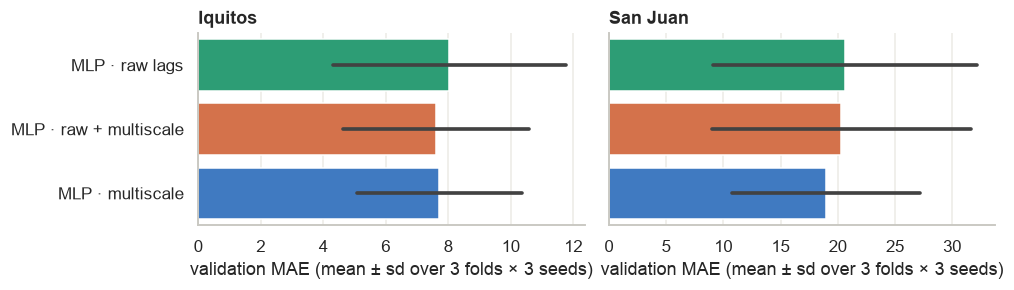

In [8]:
scores = fold_scores(representation_runs, ["model"])
scores["City"] = scores["city"].map(CITY_NAMES)
g = sns.catplot(data=scores, x="mae", y="model", col="City", kind="bar", hue="model",
                palette=SERIES[:3], errorbar="sd", sharex=False, height=2.8, aspect=1.7, legend=False,
                order=["MLP · raw lags", "MLP · raw + multiscale", "MLP · multiscale"])
g.set_titles("{col_name}")
g.set_axis_labels("validation MAE (mean ± sd over 3 folds × 3 seeds)", "")
rep_city.pivot(index="model", columns="city", values="outbreak_mae").round(2).add_prefix("outbreak MAE · ")

**Reading the result.** The question is whether the multiscale summaries
beat the raw histories, and whether *raw + multiscale* (which contains
strictly more information) is better or worse than multiscale alone.
If the combined input is worse, the gain comes from **removing**
week-to-week noise (notebook 03 §6), not from the extra summary columns.

**Answer.** Multiscale beats raw lags in both cities (San Juan 18.96 vs
20.63, Iquitos 7.71 vs 8.04) and has a much lower San Juan outbreak MAE
(59 vs 68). In San Juan, raw + multiscale (20.32) is clearly worse than
multiscale alone, so the noise-filtering explanation holds there. In
Iquitos the two are within noise (7.61 vs 7.71).

## 6. Hyper-parameter search for the multiscale MLP

Candidates vary the hidden widths, the two dropout rates and the learning
rate around the confirmed configuration (the *control*). Each candidate is
trained on 3 folds × 3 seeds. Because many candidates are compared on the
same 3 years, the best-looking one is partly lucky. **Selection rule:** a
candidate replaces the control only if its mean paired improvement
(same fold, same seed) is significant at the 5% level *after a Bonferroni
correction for the 7 candidates compared with the control* (2.69 standard
errors), and its outbreak MAE is not worse.

In [9]:
SEARCH = {
    "sj": {
        "control 100→25, d .3/.7, lr .01": MLPConfig(100, 25, 0.3, 0.7, 0.01),
        "48→12": MLPConfig(48, 12, 0.3, 0.7, 0.01),
        "64→16": MLPConfig(64, 16, 0.3, 0.7, 0.01),
        "128→32": MLPConfig(128, 32, 0.3, 0.7, 0.01),
        "100→50": MLPConfig(100, 50, 0.3, 0.7, 0.01),
        "dropout .5/.5": MLPConfig(100, 25, 0.5, 0.5, 0.01),
        "dropout .2/.5": MLPConfig(100, 25, 0.2, 0.5, 0.01),
        "lr .005": MLPConfig(100, 25, 0.3, 0.7, 0.005),
    },
    "iq": {
        "control 70→18, d .5/.5, lr .001": MLPConfig(70, 18, 0.5, 0.5, 0.001),
        "48→12": MLPConfig(48, 12, 0.5, 0.5, 0.001),
        "100→25": MLPConfig(100, 25, 0.5, 0.5, 0.001),
        "70→35": MLPConfig(70, 35, 0.5, 0.5, 0.001),
        "dropout .3/.7": MLPConfig(70, 18, 0.3, 0.7, 0.001),
        "dropout .3/.5": MLPConfig(70, 18, 0.3, 0.5, 0.001),
        "lr .003": MLPConfig(70, 18, 0.5, 0.5, 0.003),
        "lr .0005": MLPConfig(70, 18, 0.5, 0.5, 0.0005),
    },
}
start = time.time()
search_runs = pd.concat([
    run_mlp(name, F.MULTISCALE, {city: config}, cities_=(city,))
    for city in CITIES for name, config in SEARCH[city].items()
], ignore_index=True)
print(f"{search_runs.groupby(['model', 'city', 'seed', 'fold']).ngroups} fits in {time.time() - start:.0f}s")

144 fits in 245s


In [10]:
search_scores = fold_scores(search_runs, ["model"])
results = []
Z = norm.ppf(1 - 0.05 / 7)  # one-sided, 7 comparisons per city -> 2.69
for city in CITIES:
    s = search_scores[search_scores["city"].eq(city)]
    control_name = next(n for n in SEARCH[city] if n.startswith("control"))
    control = s[s["model"].eq(control_name)].set_index(["fold", "seed"])
    for name in SEARCH[city]:
        cand = s[s["model"].eq(name)].set_index(["fold", "seed"])
        diff = (cand["mae"] - control["mae"]).dropna()
        se = diff.std(ddof=1) / np.sqrt(len(diff)) if name != control_name else np.nan
        results.append({
            "city": city, "candidate": name, "mae": cand["mae"].mean(), "mae_sd": cand["mae"].std(),
            "outbreak_mae": cand["outbreak_mae"].mean(), "vs control": diff.mean(),
            "2 × SE (uncorrected)": 2 * se, "threshold (2.69 × SE)": Z * se,
            "adopt": bool(name != control_name and diff.mean() < -Z * se
                          and cand["outbreak_mae"].mean() <= control["outbreak_mae"].mean()),
        })
search_table = pd.DataFrame(results).sort_values(["city", "mae"])
search_table.round(2)

,city,candidate,mae,mae_sd,outbreak_mae,vs control,2 × SE (uncorrected),threshold (2.69 × SE),adopt
15,iq,lr .0005,7.56,2.70,23.33,-0.15,0.20,0.24,False
14,iq,lr .003,7.57,2.45,22.44,-0.14,0.33,0.40,False
9,iq,48→12,7.71,2.71,22.72,-0.00,0.27,0.34,False
8,iq,"control 70→18, d .5/.5, lr .001",7.71,2.64,22.06,0.00,NaN,NaN,False
11,iq,70→35,7.89,2.70,21.71,0.18,0.43,0.53,False
12,iq,dropout .3/.7,7.93,2.37,22.41,0.22,0.21,0.26,False
13,iq,dropout .3/.5,8.00,2.29,21.24,0.29,0.32,0.39,False
10,iq,100→25,8.11,2.29,20.76,0.40,0.55,0.68,False
3,sj,128→32,16.91,7.32,58.57,-2.05,2.33,2.85,False
1,sj,48→12,17.24,8.05,55.64,-1.72,1.78,2.19,False


{'sj': {'name': 'control 100→25, d .3/.7, lr .01',
  'hidden_1': 100,
  'hidden_2': 25,
  'dropout_1': 0.3,
  'dropout_2': 0.7,
  'learning_rate': 0.01},
 'iq': {'name': 'control 70→18, d .5/.5, lr .001',
  'hidden_1': 70,
  'hidden_2': 18,
  'dropout_1': 0.5,
  'dropout_2': 0.5,
  'learning_rate': 0.001}}

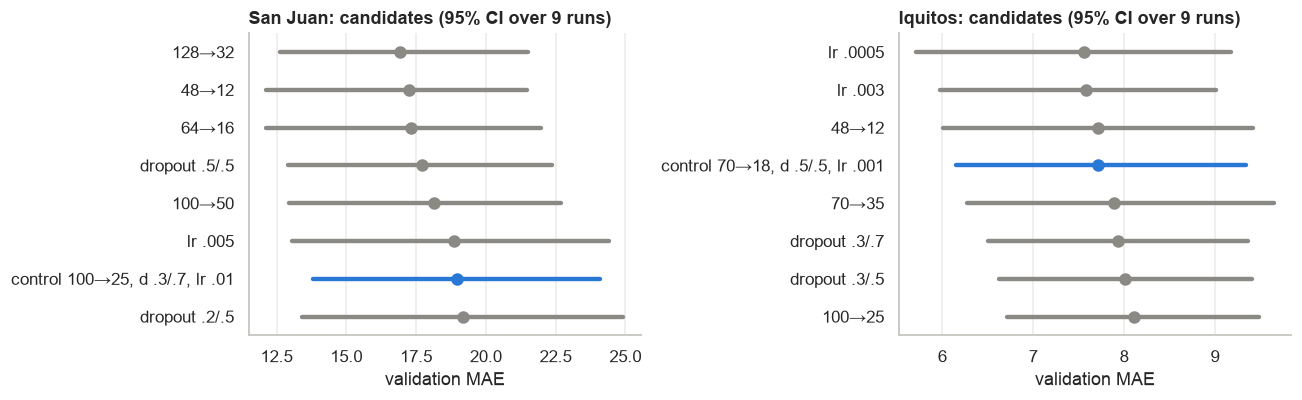

In [11]:
search_scores["City"] = search_scores["city"].map(CITY_NAMES)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, city in zip(axes, CITIES):
    data = search_scores[search_scores["city"].eq(city)]
    order = data.groupby("model")["mae"].mean().sort_values().index
    colors = {m: (SERIES[0] if m.startswith("control") else MUTED) for m in order}
    sns.pointplot(data=data, y="model", x="mae", order=order, hue="model", palette=colors,
                  errorbar=("ci", 95), linestyle="none", markersize=6, ax=ax, legend=False)
    ax.set(title=f"{CITY_NAMES[city]}: candidates (95% CI over 9 runs)", ylabel="", xlabel="validation MAE")
plt.tight_layout()

selected = {}
for city in CITIES:
    rows = search_table[search_table["city"].eq(city)]
    adopted = rows[rows["adopt"]].sort_values("mae")
    name = adopted["candidate"].iloc[0] if len(adopted) else next(n for n in SEARCH[city] if n.startswith("control"))
    selected[city] = {"name": name, **SEARCH[city][name].to_dict()}
selected

The confidence intervals overlap heavily: across 3 validation years the
differences between reasonable architectures are small compared with
the variation between seeds and between years. No candidate clears the
corrected threshold, so the control is kept for both cities.

Without the multiple-comparison correction, San Juan `100→50` would
clear the plain 2-SE bar, by 0.06 MAE. With seven candidates, one such
narrow pass is roughly what chance alone produces.

**Lesson from the hidden leaderboard.** In the original project a
narrower `48 → 12` San Juan network looked 0.22 MAE better locally, but
scored **18.1** on the hidden test against **16.6** for the control. A
small local win after trying many candidates is mostly selection noise.
This is why the rule above requires a margin larger than the noise, and
why the leaderboard-confirmed configuration is kept unless a candidate
clearly beats it.

## 7. Ablation: forecast lead time

The confirmed pipeline predicts week *t* from climate that ends at week
*t − 2* (notebook 03 §7). Does the lead matter? Same model, same seeds,
lead 0 vs lead 2:

In [12]:
lead0 = run_mlp("MLP · multiscale, lead 0", F.MULTISCALE, lag=0)
lead_compare = pd.concat([representation_runs[representation_runs["model"].eq("MLP · multiscale")], lead0])
summarize(lead_compare, ["model"])[1].round(2)

,model,iq,sj,weighted
0,MLP · multiscale,7.71,18.96,14.74
1,"MLP · multiscale, lead 0",7.66,17.78,13.99


Using same-week climate (lead 0) is slightly more accurate on the
validation years, mainly in San Juan. That is expected: the most recent
weeks carry information. The difference is about the size of the
candidate differences in section 6, and only the lead-2 version was
scored on the hidden test, so we keep lead 2. It also has the practical
advantage of a two-week reaction time and tolerance for late climate data.

## 8. Overall comparison and a tree + MLP blend

In [13]:
final_configs = {city: MLPConfig(**{k: v for k, v in selected[city].items() if k != "name"}) for city in CITIES}
if final_configs == FINAL_MLP_CONFIGS:
    final_mlp = representation_runs[representation_runs["model"].eq("MLP · multiscale")]
else:
    final_mlp = run_mlp("MLP · multiscale", F.MULTISCALE, final_configs)

def blend(tree_runs, mlp_runs, label, tree_weight=0.5):
    # Average tree and MLP predictions week by week (per MLP seed).
    t = tree_runs[["city", "fold", DATE_COLUMN, "prediction"]].rename(columns={"prediction": "tree"})
    b = mlp_runs.merge(t, on=["city", "fold", DATE_COLUMN])
    b["prediction"] = to_cases(tree_weight * b["tree"] + (1 - tree_weight) * b["prediction"])
    b["abs_error"] = (b["prediction"] - b["actual"]).abs()
    return b.drop(columns="tree").assign(model=label)

all_runs = pd.concat([
    baselines, trees,
    representation_runs[representation_runs["model"].ne("MLP · multiscale")],
    final_mlp,
    blend(trees, final_mlp, "Blend · ½ trees + ½ MLP"),
], ignore_index=True)
order = ["Median baseline", "Seasonal median", "Trees (tuned)", "MLP · raw lags", "MLP · raw + multiscale",
         "MLP · multiscale", "Blend · ½ trees + ½ MLP"]
city_summary, overall = summarize(all_runs, ["model"])
overall = overall.set_index("model").loc[order]
overall["improvement vs seasonal"] = 1 - overall["weighted"] / overall.loc["Seasonal median", "weighted"]
overall.round(3)

,iq,sj,weighted,improvement vs seasonal
model,,,,
Median baseline,7.692,21.224,16.150,-0.093
Seasonal median,7.391,19.212,14.779,0.000
Trees (tuned),7.256,12.987,10.838,0.267
MLP · raw lags,8.038,20.632,15.910,-0.077
MLP · raw + multiscale,7.613,20.325,15.558,-0.053
MLP · multiscale,7.712,18.959,14.741,0.003
Blend · ½ trees + ½ MLP,7.333,13.259,11.037,0.253


mae        outbreak_mae       
city                       iq     sj           iq     sj
model                                                   
Median baseline          7.69  21.22        28.58  82.23
Seasonal median          7.39  19.21        27.12  71.61
Trees (tuned)            7.26  12.99        25.38  45.46
MLP · raw lags           8.04  20.63        23.83  68.27
MLP · raw + multiscale   7.61  20.32        22.04  66.21
MLP · multiscale         7.71  18.96        22.06  59.09
Blend · ½ trees + ½ MLP  7.33  13.26        23.97  44.58

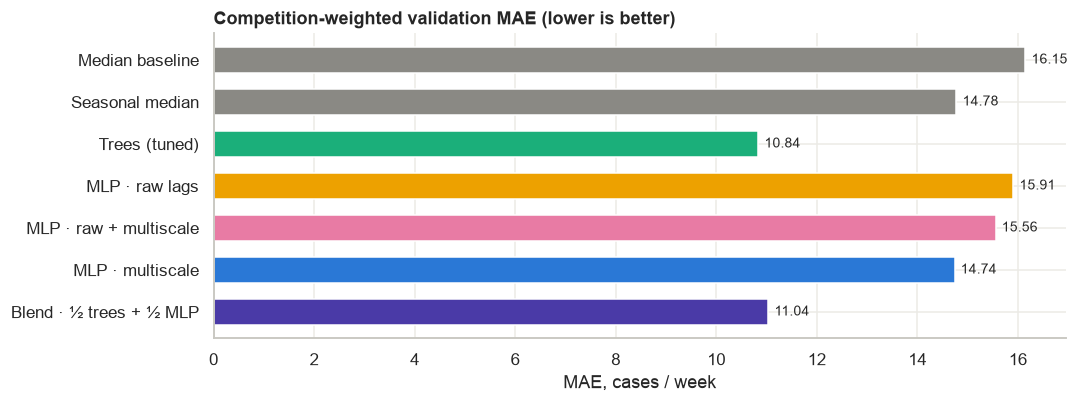

In [14]:
plot = overall.reset_index()
fig, ax = plt.subplots(figsize=(10, 3.6))
colors = [MUTED, MUTED, SERIES[2], SERIES[3], SERIES[4], SERIES[0], SERIES[6]]
bars = ax.barh(plot["model"], plot["weighted"], color=colors, height=0.6)
ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=9)
ax.invert_yaxis()
ax.set(title="Competition-weighted validation MAE (lower is better)", xlabel="MAE, cases / week")
city_summary.pivot(index="model", columns="city", values=["mae", "outbreak_mae"]).loc[order].round(2)

**Result.** On these validation years the **tree ensembles are clearly
the most accurate model** (weighted MAE 10.84), mainly because of San Juan.
The multiscale MLP is the best of the three MLP inputs but only *ties*
the seasonal median overall (14.74 vs 14.78). It does have the lowest
Iquitos outbreak MAE. The ½ + ½ blend (11.04) is close to the trees and
has the lowest San Juan outbreak MAE of all models (44.6).

## 9. A test-like multi-year holdout

The annual folds refit every year and forecast at most 52 weeks ahead.
The real test is one forecast over 5 years (San Juan) or 3 years (Iquitos),
made without refitting. To mimic that, the last 260 / 156 labelled weeks
are forecast in a single block from the weeks before them:

In [15]:
holdout = {city: temporal_folds(cities, city, n_folds=1, fold_weeks=TEST_WEEKS[city]) for city in CITIES}
print({CITY_NAMES[c]: f[0].label for c, f in holdout.items()})
long_tree = pd.concat([cross_validate(holdout[c], lambda f: predict_tree(f, train, 500, **best_tree_params[c]),
                                      model="Trees (tuned)", seed=0) for c in CITIES])
long_seasonal = pd.concat([cross_validate(holdout[c], lambda f: np.rint(seasonal_baseline(
    f.train["weekofyear"], f.train[TARGET_COLUMN], f.valid["weekofyear"])).astype(int), model="Seasonal median", seed=0)
    for c in CITIES])
long_mlp = {}
for label, representation in [("MLP · raw lags", F.RAW_LAGS), ("MLP · multiscale", F.MULTISCALE)]:
    long_mlp[label] = pd.concat([
        cross_validate(holdout[c], lambda f: predict_mlp(f, final_configs[c], representation, seed), model=label, seed=seed)
        for c in CITIES for seed in SEEDS])
long_runs = pd.concat([long_seasonal, long_tree, *long_mlp.values(),
                       blend(long_tree, long_mlp["MLP · multiscale"], "Blend · ½ trees + ½ MLP")])
summarize(long_runs, ["model"])[1].set_index("model").round(2)

{'San Juan': '2003-04 → 2008-04', 'Iquitos': '2007-07 → 2010-06'}


,iq,sj,weighted
model,,,
Blend · ½ trees + ½ MLP,7.64,16.08,12.92
MLP · multiscale,9.10,20.80,16.41
MLP · raw lags,8.01,27.97,20.48
Seasonal median,7.59,17.07,13.52
Trees (tuned),7.31,16.30,12.93


The ranking is the same as with annual folds: on every period we can
score locally, the trees (and even the seasonal median) beat the MLP,
and the blend matches the trees (12.92 vs 12.93).

## 10. Local validation vs the hidden leaderboard

The hidden test labels tell a different story:

| Model | local weighted MAE (annual folds) | hidden-test MAE |
|---|---:|---:|
| City-specific trees | best (≈ 10.8) | 22.5 |
| Multiscale MLP | ≈ 14.7 | **16.6** |

The original project's own tree validation (`artifacts/tree_validation_scores.csv`,
pooled MAE 10.1–11.4) shows the same disagreement, so it is not caused by
this notebook's folds or by the NumPy port of the network: the NumPy MLP
reproduces the original TensorFlow validation scores closely. Possible
reasons, which we cannot separate with the available labels:

* **The test years differ.** 2008–2013 includes large epidemics
  (Puerto Rico's 2010 epidemic was one of its worst on record). A
  model that keeps season-to-season amplitude can win there while losing
  on the calmer validation years.
* **Leaderboard selection.** The MLP stages were chosen after several
  submissions, so 16.6 is an optimistic estimate; 22.5 for the trees
  was not tuned on the leaderboard to the same extent.
* **Few validation years.** 3 validation years cannot represent every
  epidemic regime.

**Decision.** The submitted model is the **multiscale MLP**, because it
is the only candidate evaluated on the actual target period and it wins
there by a wide margin (16.6 vs 22.5). The local results are reported as
they are. The **½ trees + ½ MLP blend** is the natural hedge: locally it
matches the trees, and it keeps half of the MLP's amplitude. Notebook 05
writes it as a second submission file so it can be scored on the
leaderboard.

In [16]:
all_runs.to_csv(OUTPUT_DIR / "cv_predictions.csv", index=False)
long_runs.to_csv(OUTPUT_DIR / "holdout_predictions.csv", index=False)
overall.to_csv(OUTPUT_DIR / "cv_summary.csv")
search_table.to_csv(OUTPUT_DIR / "mlp_search.csv", index=False)
tree_grid.to_csv(OUTPUT_DIR / "tree_grid.csv", index=False)
(OUTPUT_DIR / "selected_models.json").write_text(json.dumps(
    {"mlp": selected, "trees": best_tree_params, "seeds": list(SEEDS)}, indent=2))
sorted(p.name for p in OUTPUT_DIR.iterdir())

['cv_predictions.csv',
 'cv_summary.csv',
 'holdout_predictions.csv',
 'mlp_search.csv',
 'selected_models.json',
 'tree_grid.csv']